# **Welcome to the Python Jupyter Notebook for processing water isotope data in the Univeristy at Buffalo Organic and Stable Isotope Biogeochemistry Laboratory! 💦**

>**How to use this code:** <br>
To run this script, click the **"Run" (play button)** for each cell in order. These chunks of code are divided into steps where the user may want to debug as they process their dataset.
>
>This Jupyter Notebook is designed to use the standardized UB OSIBL water isotope master data Excel sheets. Using other spreadsheet or data formats will likely not work because many functions reference the standardized column names.



*Adapted by - Rebecca G. Topness from Kurt R. Lindberg & Kayla Zhou <br>
Last Edited - 02/02/2026*

In [1]:
# Mount your Google Drive
# Running this cell will prompt you to log-in to your Google Account :-)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive




---


## Part 1: Set-up 🧰


---



In [2]:
# Import necessary Python packages we'll use throughout this script
import numpy as np
import pandas as pd
pd.set_option("future.no_silent_downcasting", True)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
import datetime as dt
from inspect import getmembers, isfunction
import calendar



> The following cell has a bunch of functions that help use process the data. Nothing to do here but run the cell, then we'll call the functions to use them later!

In [3]:
## SET UP FUNCTIONS

# Create a dataframe of amount-weighted monthly average isotope values
def getawma(df,start,end):

    ymd = pd.DataFrame(columns=df.columns)
    mondat = pd.DataFrame(columns=df.columns)
    awma = pd.DataFrame(columns=['Sample_ID','Precipitation_mm', 'Mean_Temperature_C', 'd18O','d2H','d_excess', 'n'])
    amfrac = []

    for year in range(start,end+1):

        for i in range(0, len(df)):
            ysample = df.Sample_ID[i]
            if int(ysample[0:4]) == year:
                ymd = pd.concat([ymd, df.loc[i].to_frame().T], ignore_index=True)

        for i in range(12):
            for j in range(0, len(ymd)):
                msample = ymd.Sample_ID[j]
                if int(msample[4:6]) == i+1:
                    mondat = pd.concat([mondat, ymd.loc[j].to_frame().T], ignore_index=True)

            for k in range(0, len(mondat)):
                amfrac.append(mondat.Precipitation_mm[k]/np.sum(mondat.Precipitation_mm))

            if np.sum(mondat.Precipitation_mm) > 0:
                awma.loc[((year-start)*12)+i, 'd18O'] = (np.sum(amfrac*mondat.d18O))/(np.sum(amfrac))
                awma.loc[((year-start)*12)+i, 'd2H'] = (np.sum(amfrac*mondat.d2H))/(np.sum(amfrac))
                awma.loc[((year-start)*12)+i, 'd_excess'] = (np.sum(amfrac*mondat.d_excess))/(np.sum(amfrac))
                awma.loc[((year-start)*12)+i, 'Precipitation_mm'] = np.sum(mondat.Precipitation_mm)
                awma.loc[((year-start)*12)+i, 'n'] = len(mondat)
            else:
                awma.loc[((year-start)*12)+i, 'd18O'] = np.nan
                awma.loc[((year-start)*12)+i, 'd2H'] = np.nan
                awma.loc[((year-start)*12)+i, 'd_excess'] = np.nan
                awma.loc[((year-start)*12)+i, 'Precipitation_mm'] = np.nan
                awma.loc[((year-start)*12)+i, 'n'] = 0

            awma.loc[((year-start)*12)+i, 'Mean_Temperature_C'] = np.mean(mondat.Mean_Temperature_C)

            if i+1 <= 9:
                awma.loc[((year-start)*12)+i, 'Sample_ID'] = (str(year) + '0' + str(i+1) + '01')
            else:
                awma.loc[((year-start)*12)+i, 'Sample_ID'] = (str(year) + str(i+1) + '01')

            mondat = pd.DataFrame(columns=df.columns)
            amfrac = []

        ymd = pd.DataFrame(columns=df.columns)

    return awma


# Calculate monthly amount-weighted values averaged across all years of data collection
def monthclim(df):

    mondat = pd.DataFrame(columns=df.columns)
    monclim = pd.DataFrame(columns=['month','d2H','d18O','d_excess'])
    amfrac = []

    for i in range(12):
        for j in range(0, len(df)):
            msample = df.Sample_ID[j]
            if int(msample[4:6]) == i+1:
                mondat = pd.concat([mondat, df.loc[j].to_frame().T], ignore_index=True)

        for k in range(0, len(mondat)):
            amfrac.append(mondat.Precipitation_mm[k]/np.sum(mondat.Precipitation_mm))

        if np.sum(mondat.Precipitation_mm) > 0:
            monclim.loc[i, 'd2H'] = (np.sum(amfrac*mondat.d2H)/np.sum(amfrac))
            monclim.loc[i, 'd18O'] = (np.sum(amfrac*mondat.d18O)/np.sum(amfrac))
            monclim.loc[i, 'd_excess'] = (np.sum(amfrac*mondat.d_excess)/np.sum(amfrac))
        else:
            monclim.loc[i, 'd2H'] = np.nan
            monclim.loc[i, 'd18O'] = np.nan
            monclim.loc[i, 'd_excess'] = np.nan

        monclim.loc[i, 'month'] = calendar.month_abbr[i+1]

        mondat = pd.DataFrame(columns=df.columns)
        amfrac = []

    return monclim

# Calculate amount-weighted annual averages for each year
def yearclim(df,start,end,mod):

    yeardat = pd.DataFrame(columns=df.columns)
    yclim = pd.DataFrame(columns=['year','d2H','d18O','d_excess'])
    amfrac = []

    for i in range(start, end + mod):
        for j in range(0, len(df)):
            ysample = df.Sample_ID[j]
            if int(ysample[0:4]) == i:
                yeardat = pd.concat([yeardat, df.loc[j].to_frame().T], ignore_index=True)

        for k in range(0, len(yeardat)):
            amfrac.append(yeardat.Precipitation_mm[k]/np.sum(yeardat.Precipitation_mm))

        if np.sum(yeardat.Precipitation_mm) > 0:
            yclim.loc[(i-start), 'd2H'] = (np.sum(amfrac*yeardat.d2H)/np.sum(amfrac))
            yclim.loc[(i-start), 'd18O'] = (np.sum(amfrac*yeardat.d18O)/np.sum(amfrac))
            yclim.loc[(i-start), 'd_excess'] = (np.sum(amfrac*yeardat.d_excess)/np.sum(amfrac))
        else:
            yclim.loc[(i-start), 'd2H'] = np.nan
            yclim.loc[(i-start), 'd18O'] = np.nan
            yclim.loc[(i-start), 'd_excess'] = np.nan

        yclim.loc[(i-start), 'year'] = i

        yeardat = pd.DataFrame(columns=df.columns)
        amfrac = []

    return yclim



---

## Part 2: Load in the dataset ⌛

---





> Now we'll load in the datasets. First, set your working directory. This will be the folder where the datasets (Excel files) are located. <br>
It should start with '/content/drive/MyDrive/' but the folder (called data in the example) might change depending on where you've saved your files! <br>
Here's an example:

```
dir = '/content/drive/MyDrive/data/
```




In [4]:
# Set your working directory here
dir = '/content/drive/MyDrive/data/'

> Let's read in a dataset. In this cell, you'll need to edit the 'df_name' to read in the name of the Excel file in your directory.

```
df_name = '20250715_Cooke Master Data.xlsx' # EDIT THE NAME HERE
```



In [6]:
# Give the name of the file you'd like to load in
df_name = '20250715_Cooke Master Data.xlsx' #### EDIT THE NAME HERE ####
#df_name = '20250715_Skaneateles Master Data.xlsx'

sites = pd.read_excel(dir+df_name, sheet_name='Sites') # This line reads in the 'Sites' tab of the Excel sheet

location = str(sites.City[0]) + ', ' + str(sites.State_or_Province[0]) # Location data is pulled from the 'Sites' tab from the Excel sheet

widat = pd.read_excel(dir+df_name, sheet_name='Sample_Isotope_Climate') # Read in the climate and isotope data, from the tab called 'Sample_Isotope_Climate'

widat = widat.dropna(subset=['Sample_ID'])
widat = widat.reset_index(drop=True) #reset the index

bug_tokens = {
    'NaNa': np.nan,
    'NA': np.nan,
    '-': np.nan,
    '#VALUE!': np.nan,
    '#VALUE': np.nan,
}
# Remove notes that are handwritten in the datasets to NaNs, so python can read them!
widat = widat.replace(bug_tokens)

# Make sure columns are numeric (bug for calculations!)
widat['Precipitation_mm'] = pd.to_numeric(widat['Precipitation_mm'], errors = 'coerce')
widat['Mean_Temperature_C'] = pd.to_numeric(widat['Mean_Temperature_C'], errors = 'coerce')
widat['d2H']  = pd.to_numeric(widat['d2H'], errors='coerce')
widat['d18O'] = pd.to_numeric(widat['d18O'], errors='coerce')

# Add a date column
widat['date'] = widat['Sample_ID'].str[0:8]
widat['date'] = pd.to_datetime(widat['date'].astype(str), format = '%Y%m%d')

# Show the first few rows to the dataset, so we can check if we loaded it in correctly
widat.head()

,Sample_Source,Start_Date,Start_Time_Zone,Collection_Date_Collection_Time,Collection_Time_Zone,Site_ID,Multiday sample? (# days),Phase,Sample_Comments,Type,...,Rain amount (in),Temp (F),Precipitation_mm,Mean_Temperature_C,Min_Temperature_C,Max_Temperature_C,Vapor_Pressure_hPa,Climate_Source,Climate_Comments,date
0,EKT,NaN,GMT-4,2014-08-12 10:45:00,GMT-4,201408121045CHR,NaN,liquid,Broken Vial,precipitation,...,NaN,NaN,5.080,22.222222,NaN,NaN,NaN,NaN,NaN,2014-08-12
1,EKT,NaN,NaN,2014-08-13 11:20:00,GMT-4,201408131120CHR,NaN,liquid,Sample not analyzed,NaN,...,NaN,NaN,19.812,20.000000,NaN,NaN,NaN,NaN,NaN,2014-08-13
2,EKT,NaN,NaN,2014-08-15 11:45:00,GMT-4,201408151145CHR,NaN,liquid,Sample not analyzed,NaN,...,NaN,NaN,NaN,17.222222,NaN,NaN,NaN,NaN,NaN,2014-08-15
3,EKT,NaN,NaN,2014-08-18 12:40:00,GMT-4,201408181240CHR,NaN,liquid,NaN,NaN,...,NaN,NaN,4.572,21.111111,NaN,NaN,NaN,NaN,NaN,2014-08-18
4,NaN,NaN,NaN,2014-08-28 15:00:00,GMT-4,201408281500CHR,NaN,solid,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-08-28




---

## Part 3: Filter the dataset 🔎

---



> We'll process the dataset so we have three different versions: a dataframe called 'widat', 'widat_i', and 'widat_ia'


```
widat = all the data, unedited from the Excel sheet

widat_i = data filtered for having isotope data (i.e. some days don't have a sample and/or not enough water to analyze)

widat_ia = data filtered for having precipitation amount data (i.e. to calculate amount-weighted averages,
we need to know the amount that fell!)
```

> We'll also calculate d-excess. D-excess represents the excess amount of deuterium compared to heavy oxygen (18O) in water. It can be used as a proxy for evaporation, with high d-excess values meaning more evaporation.


```
d-excess = δ2H − 8 * δ18O
```

> Run the cell below to do that.



In [7]:
# Filter data by processing requirements (i.e. having isotope data, precipitation amount)

widat_i = widat[widat['d18O'].notna()] # only removes samples with missing isotope data
#widat_i = widat[(widat['d18O'].notna()) & (widat['Sample_Ignore'] == 0)] # removes samples either missing isotope data or are flagged to ignore
widat_i = widat_i.reset_index(drop=True) # reset the dataframe index to continuous, whole number integers starting at 0

# Calculate d-excess values for each sample containing isotope measurements
d_excess = np.array(widat_i.d2H) - 8*np.array(widat_i.d18O) # calculate d-excess for all samples using d2H and d18O data
widat_i['d_excess'] = d_excess # adds column of d-excess results to the widat_i dataframe

#print(d_excess) # check that d-excess was calculated correctly
#print(widat_i.columns) # check that d-excess column was added to widat_i correctly

widat_ia = widat_i[widat_i['Precipitation_mm'].notna()] # removes samples with missing precipitation amount measurements; cannot be used for amount-weighted calculations
widat_ia = widat_ia.reset_index(drop=True)

# Calculate number of rows removed after filtering
rows_removed_widat_i = len(widat) - len(widat_i)
print(f"Number of rows removed after filtering by isotope data and ignore flag: {rows_removed_widat_i}")

rows_removed_widat_ia = len(widat_i) - len(widat_ia)
print(f"Number of rows removed after filtering by precipitation data: {rows_removed_widat_ia}")

# Check out the first few rows of the filtered dataset (this dataset only includes samples that also have precip amount for that day)
widat_ia.head()

Number of rows removed after filtering by isotope data and ignore flag: 73
Number of rows removed after filtering by precipitation data: 25


,Sample_Source,Start_Date,Start_Time_Zone,Collection_Date_Collection_Time,Collection_Time_Zone,Site_ID,Multiday sample? (# days),Phase,Sample_Comments,Type,...,Temp (F),Precipitation_mm,Mean_Temperature_C,Min_Temperature_C,Max_Temperature_C,Vapor_Pressure_hPa,Climate_Source,Climate_Comments,date,d_excess
0,EKT,NaN,GMT-4,2014-08-12 10:45:00,GMT-4,201408121045CHR,NaN,liquid,Broken Vial,precipitation,...,NaN,5.080,22.222222,NaN,NaN,NaN,NaN,NaN,2014-08-12,11.17
1,EKT,NaN,NaN,2014-08-18 12:40:00,GMT-4,201408181240CHR,NaN,liquid,NaN,NaN,...,NaN,4.572,21.111111,NaN,NaN,NaN,NaN,NaN,2014-08-18,0.43
2,EKT,NaN,NaN,2014-09-02 09:40:00,GMT-4,201409020940CHR,NaN,liquid,NaN,NaN,...,NaN,5.334,23.888889,NaN,NaN,NaN,NaN,NaN,2014-09-02,7.61
3,EKT,NaN,NaN,2014-09-03 12:40:00,GMT-4,201409031240CHR,NaN,liquid,NaN,NaN,...,NaN,4.064,23.888889,NaN,NaN,NaN,NaN,NaN,2014-09-03,12.61
4,EKT,NaN,NaN,2014-09-05 13:30:00,GMT-4,201409051330CHR,NaN,liquid,NaN,NaN,...,NaN,5.842,27.777778,NaN,NaN,NaN,NaN,NaN,2014-09-05,0.68




---


## Part 4: Calculate amount-weighted monthly average precipitation isotope values 🌧


---



> Now we'll take our event-based dataset, and calculate amount-weighted monthly averages. This will give us an idea of the precipitation isotope values for all the rainfall/snowfall events that happened in any month during the year. <br> Run the cell below to do that.

In [8]:
# Calculate amount-weighted monthly average (awma) precipitation isotope values

start_year = int(np.min(widat['date'].dt.year)) # Get the first year of data collection
end_year = int(np.max(widat['date'].dt.year)) # Get the last year of data collection

awma = getawma(widat_ia, start_year, end_year) # use the getawma() function to calculate amount-weighted monthly averages for every month in the dataset
# includes d2H, d18O, d-excess, and total precipitation

awma = awma.dropna() # Remove values that are 'nan'; months without any data are assigned 'nan' (not a number)

# Add date, Year, and Month columns
awma['date'] = pd.to_datetime(awma['Sample_ID'].astype(str), format='%Y%m%d')
awma['year'] = awma['date'].dt.year
awma['month'] = awma['date'].dt.month

# Save the output to a new Excel file, if you want!
#awma.to_excel(dir + str(location) + '_awma.xlsx') # save amount-weighted averages to a new Excel sheet in your working directory

> Let's check out what the amount-weighted monthly mean dataset looks like.

In [9]:
# Check out the first few rows of the amount-weighted dataset
awma.head()

,Sample_ID,Precipitation_mm,Mean_Temperature_C,d18O,d2H,d_excess,n,date,year,month
7,20140801,9.652,21.666667,-5.697368,-39.496316,6.082632,2,2014-08-01,2014,8
8,20140901,64.008,20.0,-6.799365,-40.50377,13.891151,7,2014-09-01,2014,9
11,20141201,37.592,2.361111,-10.569595,-70.77973,13.777027,4,2014-12-01,2014,12
14,20150301,35.56,1.111111,-13.056429,-100.838571,3.612857,3,2015-03-01,2015,3
15,20150401,38.1,8.240741,-8.098,-54.596,10.188,6,2015-04-01,2015,4


___
---
## Phew! 😅 That was a lot of data processing. Now that we've got our data processed, let's make some figures! 🎉
___
---

---
## Plot #1: Co-Isotope Plot 🎨
---

> **Co-isotope plots** (also called dual-isotope plots) plots two different isotopic ratios together. For our precipitation isotope samples, **we plot d2H (ratio of the heavy and light hydrogen isotopes) on the y-axis and d18O (ratio of the heavy and light oxygen isotopes) on the x-axis.**
>
> Using this plot, we can also calculate the **Local Meteoric Water Line (LMWL)**. This defines the relationship bewteen H and O isotopes in precipitation.
>
>
> We'll compare the LWML with the **Global Meteoric Water Line (GMWL)**, which defines that relationship for precipitation over the whole world.
>
> The GWML is defined as: **δ2H = 8 * δ18O + 10**, where the slope = 8 and the intercept = 10.
>
> See below for an example co-isotope plot from [Burnett et al. (2004)](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2004GL021089):

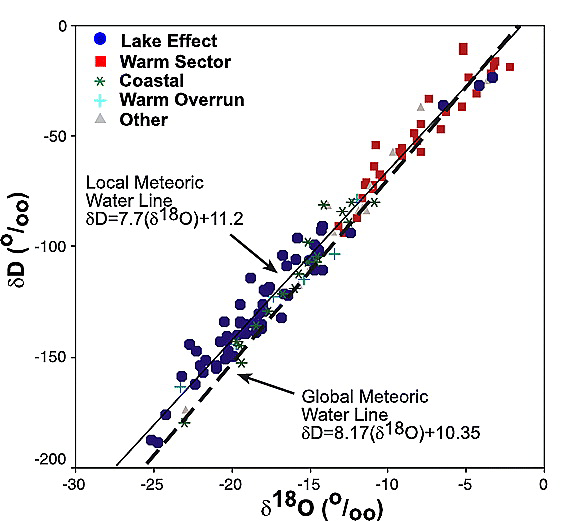

> Run the cell below to calculate the Local Meteoric Water Line for your dataset.

In [10]:
# Set-up the Global Meteoric Water Line
gmwl_x = np.array(widat_i.d18O) # use awma d18O values as x-axis points from which to calculate y-axis points along the GMWL
gmwl_y = gmwl_x*8 + 10 # GMWL equation relating d2H and d18O (Dansgaard, 1964)

# Calculate Local Meteoric Water Line for our site!
model = LinearRegression().fit(np.array(awma.d18O).reshape((-1,1)), np.array(awma.d2H)) # use the LinearRegression package to perform a linear fit to the awma d2H and d18O results
lmwl_x = np.array(widat_i.d18O) # use awma d18O values as x-axis points from which to calculate y-axis points along the LMWL
lmwl_y = lmwl_x*model.coef_ + model.intercept_ # LWML equation relating d2H and d18O based on the slope and intercept of the linear fit

print('LMWL Slope = ' + str(model.coef_)) # display the LMWL slope
print('LMWL Y-Intercept = ' + str(model.intercept_)) # display the LMWL y-intercept

# Calculte montly and annual climatology averages + assign months for binning
mclim = monthclim(widat_ia)
yclim = yearclim(widat_ia, start_year, end_year, 0) # last argument can be changed to 1 to include the most recent sampling year if complete

#print(mclim) # display amount-weighted results for each month averages across all years of data collection
#print(yclim) # display amount-weighted annual average results


LMWL Slope = [7.36905309]
LMWL Y-Intercept = 5.581080062805725


> How do the slope and intercept above for our LMWL compare to the GMWL? 🔍

<Figure size 640x480 with 0 Axes>

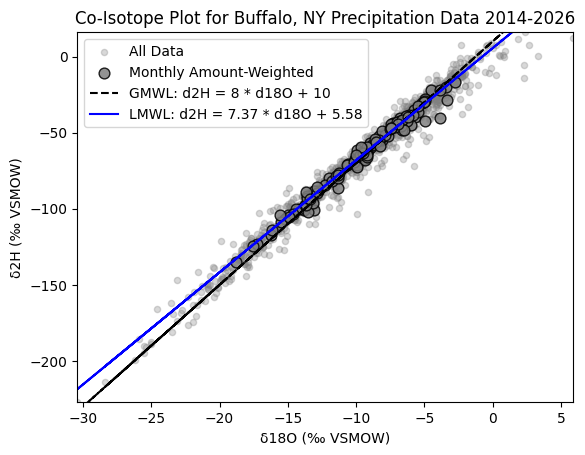

In [11]:
# Generate co-isotope plot with GMWL and LMWL

plt.figure(1)
fig, ax = plt.subplots(1, 1)

ax.scatter(widat_i.d18O, widat_i.d2H, color='gray', s=20, alpha=0.30, label='All Data')
ax.scatter(awma.d18O, awma.d2H, c='gray', edgecolors='black', s=60, alpha=0.85, label='Monthly Amount-Weighted')
ax.plot(gmwl_x, gmwl_y, color='black', linestyle='--', label='GMWL: d2H = 8 * d18O + 10')
ax.plot(lmwl_x, lmwl_y, color='blue', label=('LMWL: d2H = ' + str(round(np.float64(model.coef_[0]), 2)) + ' * d18O ' + '+ ' + str(round(model.intercept_, 2))))
ax.set_xlim([np.min(widat_i.d18O), np.max(widat_i.d18O)])
ax.set_ylim([np.min(widat_i.d2H), np.max(widat_i.d2H)])
ax.set_xlabel('δ18O (‰ VSMOW)')
ax.set_ylabel('δ2H (‰ VSMOW)')
ax.legend()
ax.set_title('Co-Isotope Plot for ' + str(location) + ' Precipitation Data ' + str(start_year) + '-' + str(end_year))

# Show the figure
figure1 = plt.gcf()

# Save generated figure to your working directory
#figure1.savefig(dir + 'widat_co-isotope.pdf') # uncomment this line to save this figure as a .pdf
figure1.savefig(dir + 'widat_co-isotope.png') # uncomment this line to save this figure as a .png

---
## Plot #2: Timeseries 🎨
---

<Figure size 640x480 with 0 Axes>

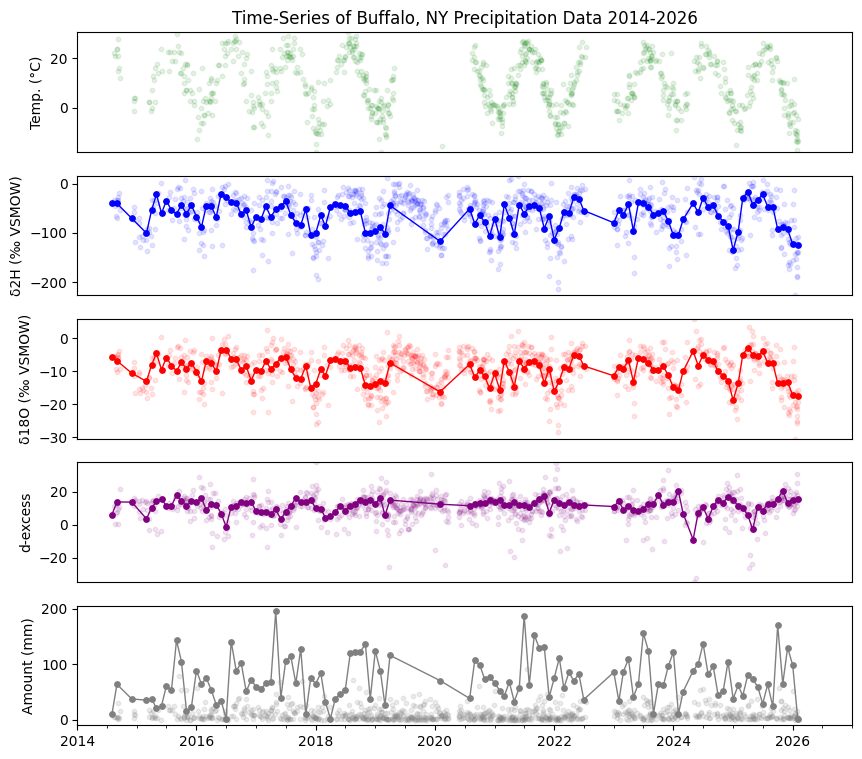

In [12]:
# Generate time-series plots of water isotope and climate data

plt.figure(2)
fig, axs = plt.subplots(nrows = 5, ncols = 1, figsize = (10,9))

ax = axs[0]
ax.set_title('Time-Series of ' + str(location) + ' Precipitation Data ' + str(start_year) + '-' + str(end_year))

ax.scatter(widat_ia['date'], widat_ia.Mean_Temperature_C, color = 'green', s=10, alpha=0.1)

ax.set_ylim([np.min(widat_ia.Mean_Temperature_C), np.max(widat_ia.Mean_Temperature_C)])
ax.set_xlim(dt.datetime.strptime(str(start_year), '%Y').date(), dt.datetime.strptime(str(end_year+1), '%Y').date())
ax.set_xticks([])
ax.set_ylabel('Temp. (°C)')

ax = axs[1]
ax.scatter(widat_i['date'], widat_i.d2H, s=10, alpha=0.10, color='blue')
ax.plot(awma['date'], awma.d2H, linewidth=1, color='blue')
ax.scatter(awma['date'], awma.d2H, s=15, color='blue')
ax.set_ylim([np.min(widat_i.d2H), np.max(widat_i.d2H)])
ax.set_xlim(dt.datetime.strptime(str(start_year), '%Y').date(), dt.datetime.strptime(str(end_year+1), '%Y').date())
ax.set_xticks([])
ax.set_ylabel('δ2H (‰ VSMOW)')

ax = axs[2]
ax.scatter(widat_i['date'], widat_i.d18O, s=10, alpha=0.10, color='red')
ax.plot(awma['date'], awma.d18O, linewidth=1, color='red')
ax.scatter(awma['date'], awma.d18O, s=15, color='red')
ax.set_ylim([np.min(widat_i.d18O), np.max(widat_i.d18O)])
ax.set_xlim(dt.datetime.strptime(str(start_year), '%Y').date(), dt.datetime.strptime(str(end_year+1), '%Y').date())
ax.set_xticks([])
ax.set_ylabel('δ18O (‰ VSMOW)')

ax = axs[3]
ax.scatter(widat_i['date'], widat_i.d_excess, s=10, alpha=0.10, color='purple')
ax.plot(awma['date'], awma.d_excess, linewidth=1, color='purple')
ax.scatter(awma['date'], awma.d_excess, s=15, color='purple')
ax.set_ylim([np.min(widat_i.d_excess), np.max(widat_i.d_excess)])
ax.set_xlim(dt.datetime.strptime(str(start_year), '%Y').date(), dt.datetime.strptime(str(end_year+1), '%Y').date())
ax.set_xticks([])
ax.set_ylabel('d-excess')

ax = axs[4]
ax.scatter(widat_ia['date'], widat_ia.Precipitation_mm, s=10, alpha=0.15, color='gray')
ax.plot(awma['date'], awma.Precipitation_mm, linewidth=1, color='gray')
ax.scatter(awma['date'], awma.Precipitation_mm, s=15, color='gray')
ax.set_xlim(dt.datetime.strptime(str(start_year), '%Y').date(), dt.datetime.strptime(str(end_year+1), '%Y').date())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 7)))
#ax.set_ylim(0,200)
ax.set_ylabel('Amount (mm)')

figure2 = plt.gcf()
#figure2.savefig(dir + 'widat_time_series.pdf') # uncomment this line to save this figure as a .pdf
figure2.savefig(dir + 'widat_time_series.png') # uncomment this line to save this figure as a .png



___
## Plot #3: Climatology 🎨
___

> Climatologies are usually made up of a few decades (~30 years), and show the overall seasonal cycle for a location. <br>
> Here, we'll aggregate our data over all the years in the dataset by taking means (or sums).

<Figure size 640x480 with 0 Axes>

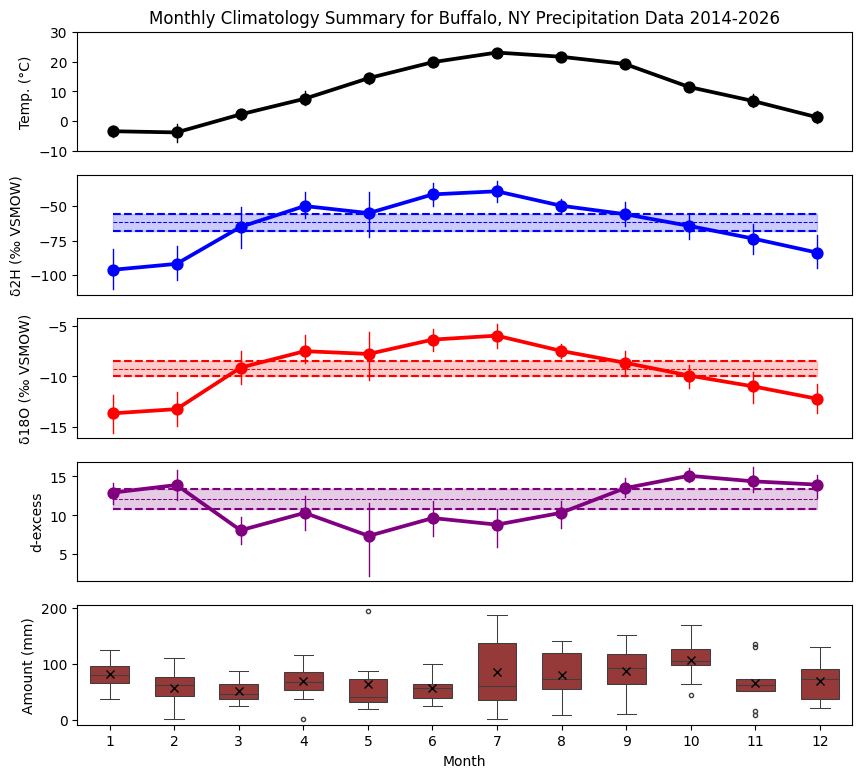

In [13]:
# Generate monthly climatology summary

plt.figure(3)
fig, axs = plt.subplots(nrows = 5, ncols = 1, figsize = (10,9))

ax = axs[0]
ax.set_title('Monthly Climatology Summary for ' + str(location) + ' Precipitation Data ' + str(start_year) + '-' + str(end_year))

# Air temperature
ax = axs[0]
# Might be a better way to show this than a box plot!
sns.pointplot(ax=ax, x = awma['month'], y = awma['Mean_Temperature_C'], color='black', err_kws={'linewidth': 1})
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(widat.Mean_Temperature_C) + np.std(widat.Mean_Temperature_C)), color='k', linestyle='--')
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(widat.Mean_Temperature_C) - np.std(widat.Mean_Temperature_C)), color='k', linestyle='--')
ax.set_xlabel('')
ax.set_xticks([])
ax.set_ylabel('Temp. (°C)')
ax.set_ylim(-10,30)

# Precip d2H
ax = axs[1]
sns.pointplot(ax=ax, x = awma['month'], y = awma['d2H'], color='blue', err_kws={'linewidth': 1})
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d2H)), color='blue', linestyle='--', linewidth=0.75)
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d2H) + np.std(yclim.d2H)), color='blue', linestyle='--')
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d2H) - np.std(yclim.d2H)), color='blue', linestyle='--')
ax.fill_between(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d2H) + np.std(yclim.d2H)), np.full((12,), np.average(yclim.d2H) - np.std(yclim.d2H)), color='blue', alpha=0.2)
#ax.set_ylim([np.min(mclim.d2H)-10, np.max(mclim.d2H)+10])
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('δ2H (‰ VSMOW)')

# Precip d18O
ax = axs[2]
sns.pointplot(ax=ax, x = awma['month'], y = awma['d18O'], color='red', err_kws={'linewidth': 1})
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d18O)), color='red', linestyle='--', linewidth=0.75)
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d18O) + np.std(yclim.d18O)), color='red', linestyle='--')
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d18O) - np.std(yclim.d18O)), color='red', linestyle='--')
ax.fill_between(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d18O) + np.std(yclim.d18O)), np.full((12,), np.average(yclim.d18O) - np.std(yclim.d18O)), color='red', alpha=0.2)
#ax.set_ylim([np.min(mclim.d18O)-2, np.max(mclim.d18O)+2])
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('δ18O (‰ VSMOW)')

# Precip amount
ax = axs[3]
sns.pointplot(ax=ax, x = awma['month'], y = awma['d_excess'], color='purple', err_kws={'linewidth': 1})
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d_excess)), color='purple', linestyle='--', linewidth=0.75)
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d_excess) + np.std(yclim.d_excess)), color='purple', linestyle='--')
ax.plot(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d_excess) - np.std(yclim.d_excess)), color='purple', linestyle='--')
ax.fill_between(np.linspace(0, 11, num=12), np.full((12,), np.average(yclim.d_excess) + np.std(yclim.d_excess)), np.full((12,), np.average(yclim.d_excess) - np.std(yclim.d_excess)), color='purple', alpha=0.2)
#ax.set_ylim([np.min(mclim.d_excess)-1, np.max(mclim.d_excess)+1])
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('d-excess')

ax = axs[4]
sns.boxplot(ax=ax, x = awma['month'], y = awma['Precipitation_mm'], color='brown', width=0.6, linewidth=0.75, fliersize=3, showmeans=True, meanprops={"marker":"x","markerfacecolor":"black","markeredgecolor":"black","markersize":"6"})
ax.set_ylabel('Amount (mm)')
ax.set_xlabel('Month')

figure3 = plt.gcf()
#figure3.savefig(dir + 'widat_climatology_summary.pdf') # uncomment this line to save this figure as a .pdf
figure3.savefig(dir + 'widat_climatology_summary.png') # uncomment this line to save this figure as a .png

> Yay you did it! 🌈 Let rgtopnes@buffalo.edu know if there's any bugs 🐞